In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [27]:
df=pd.read_csv('train.csv')
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [28]:
df.shape

(700000, 26)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [30]:
df.isnull().mean()*100

id                                    0.0
age                                   0.0
alcohol_consumption_per_week          0.0
physical_activity_minutes_per_week    0.0
diet_score                            0.0
sleep_hours_per_day                   0.0
screen_time_hours_per_day             0.0
bmi                                   0.0
waist_to_hip_ratio                    0.0
systolic_bp                           0.0
diastolic_bp                          0.0
heart_rate                            0.0
cholesterol_total                     0.0
hdl_cholesterol                       0.0
ldl_cholesterol                       0.0
triglycerides                         0.0
gender                                0.0
ethnicity                             0.0
education_level                       0.0
income_level                          0.0
smoking_status                        0.0
employment_status                     0.0
family_history_diabetes               0.0
hypertension_history              

In [31]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(exclude='number').columns

<Axes: >

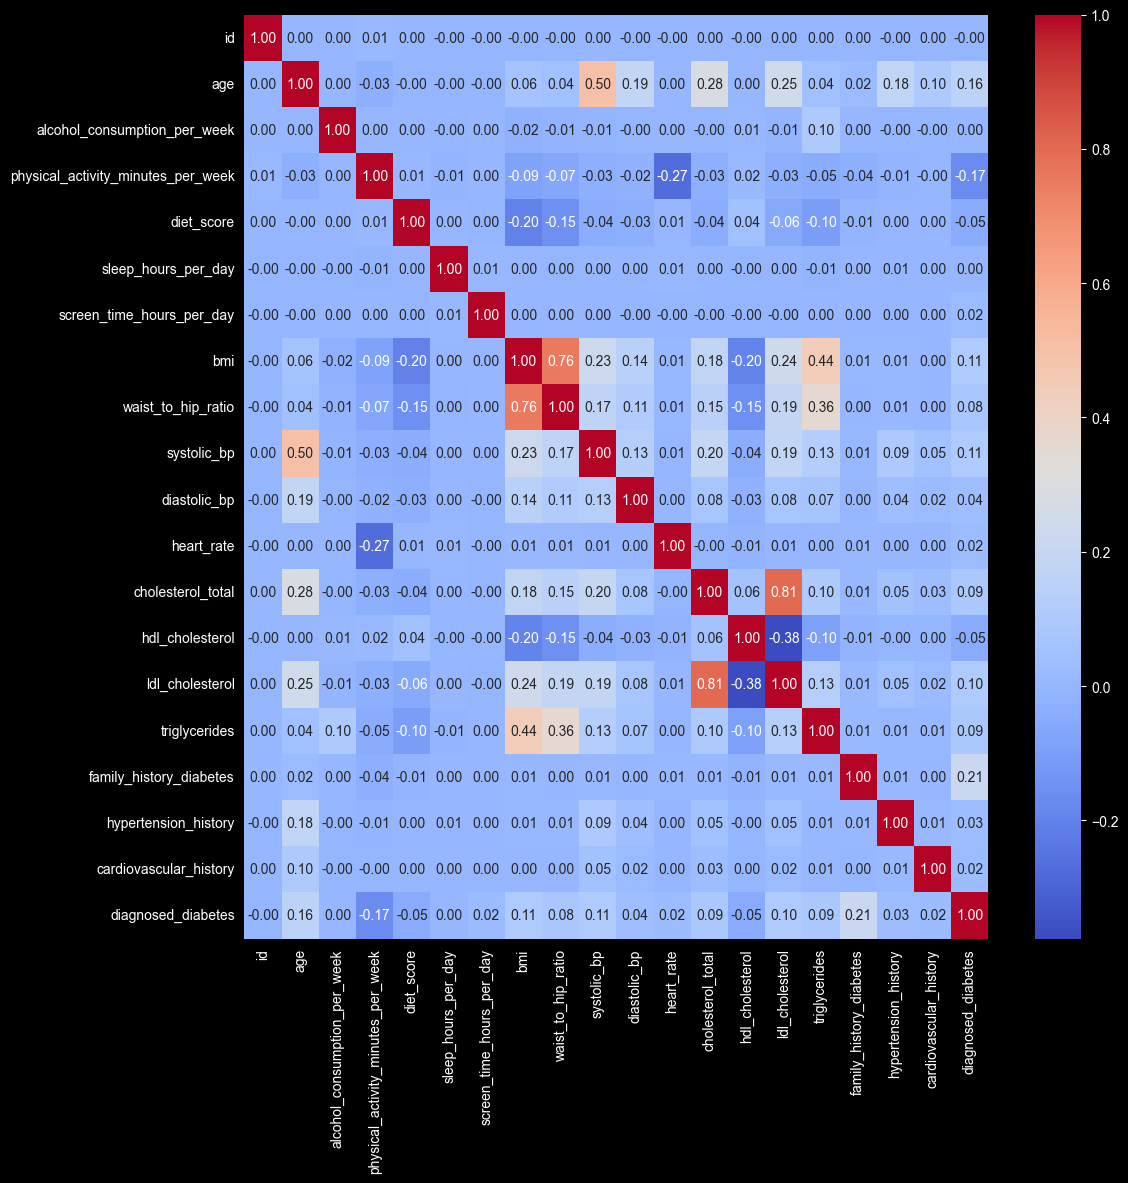

In [33]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,12))
sns.heatmap(corr,annot=True, fmt=".2f", cmap="coolwarm")

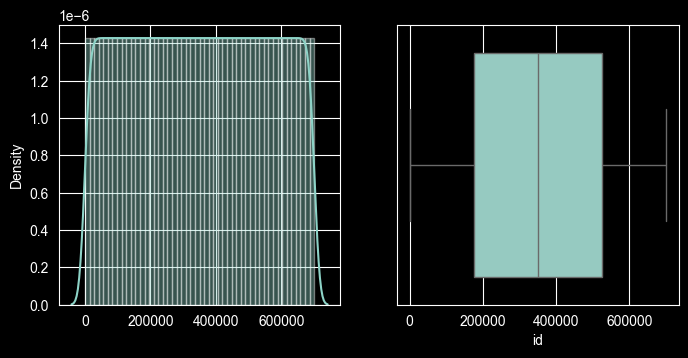

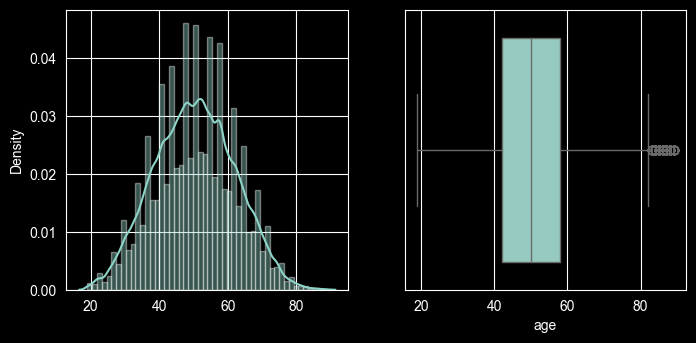

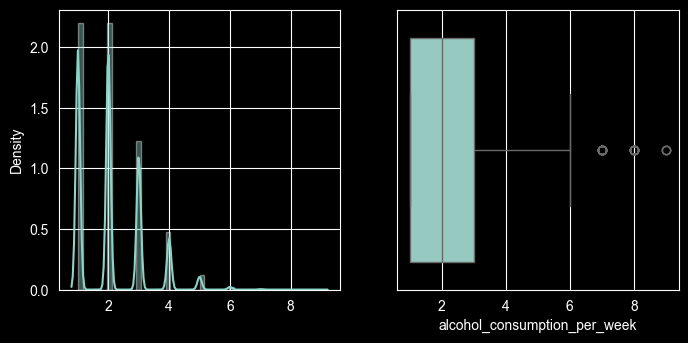

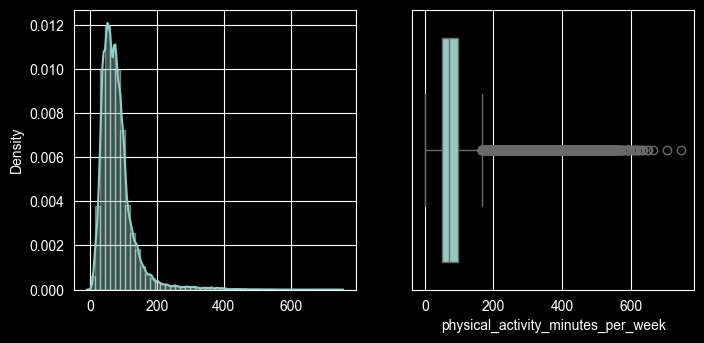

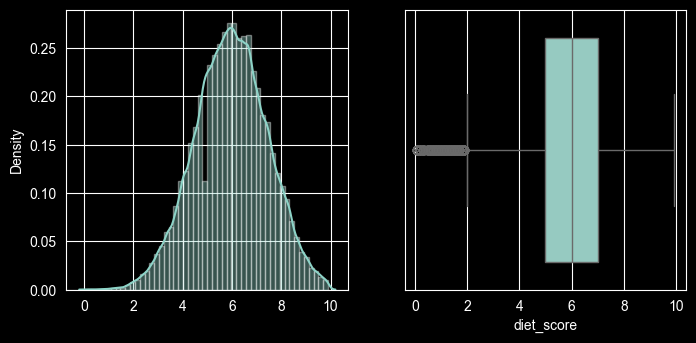

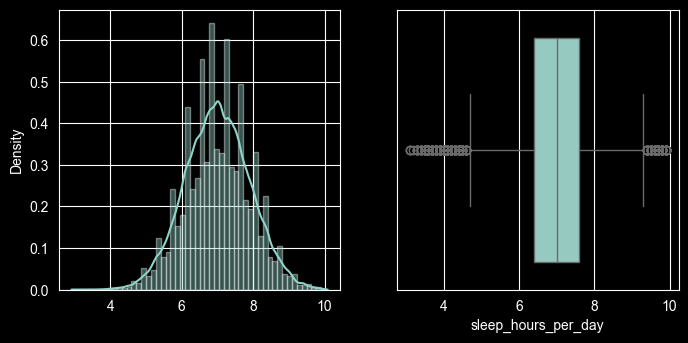

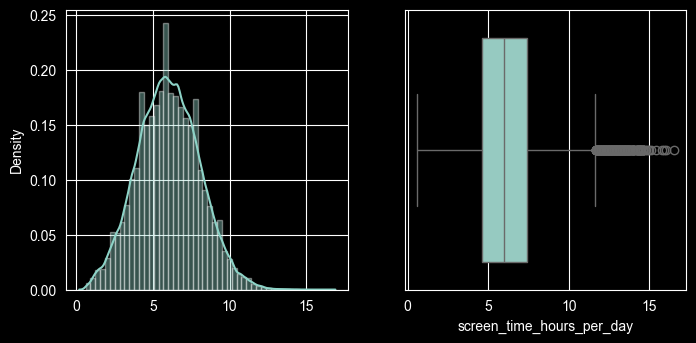

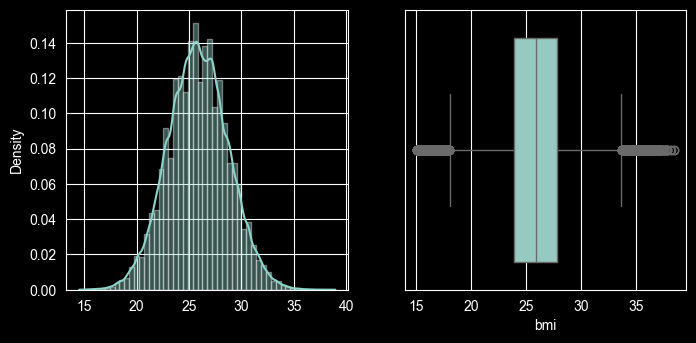

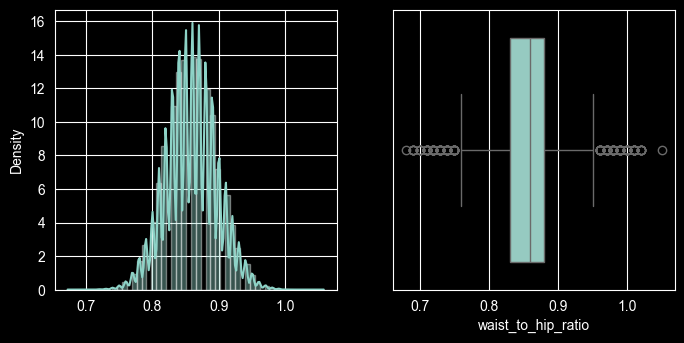

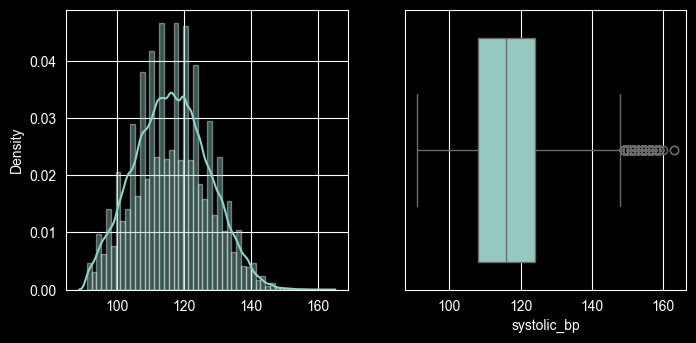

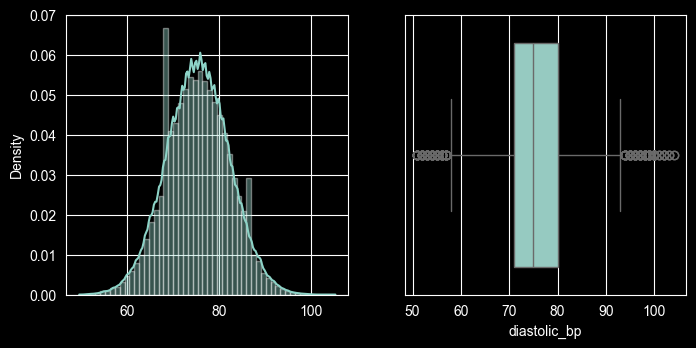

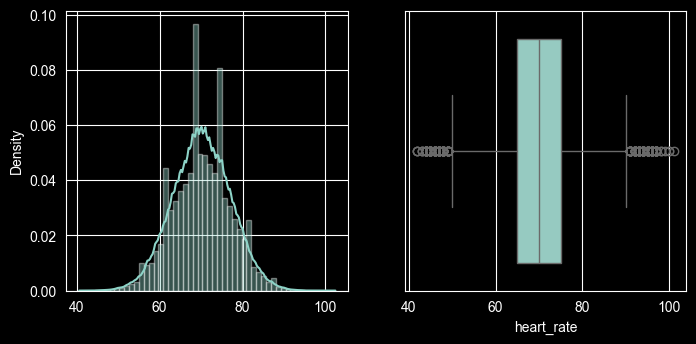

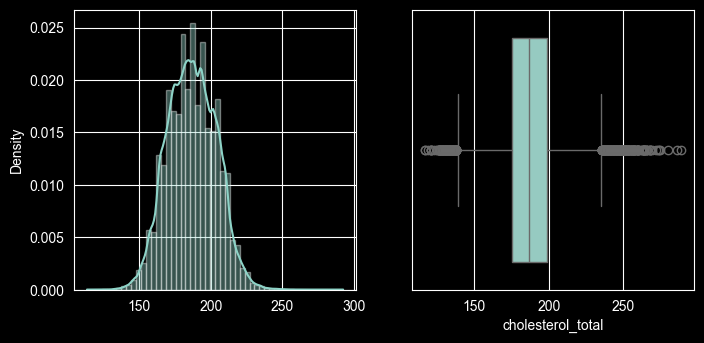

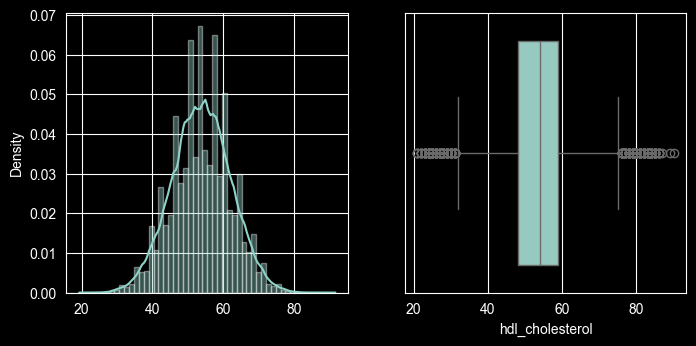

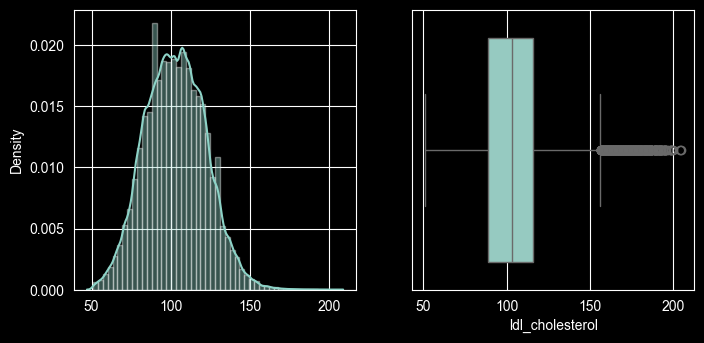

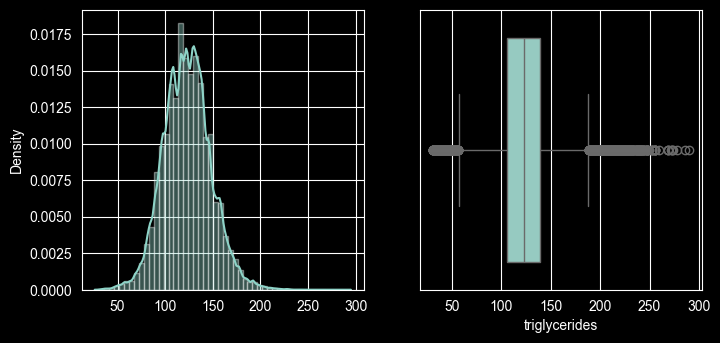

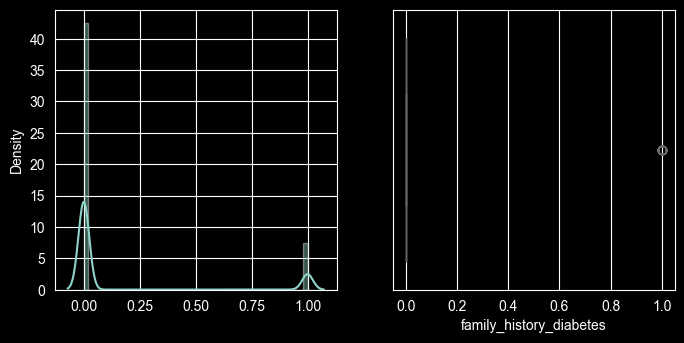

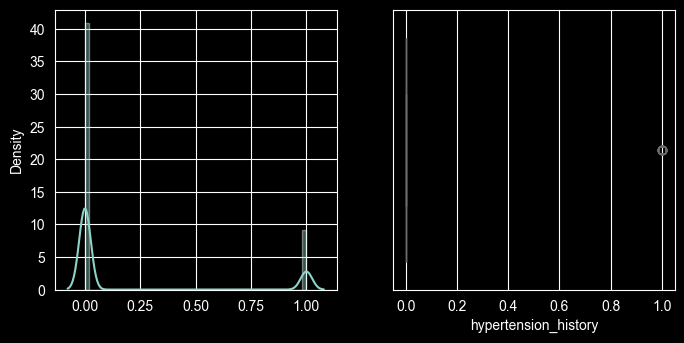

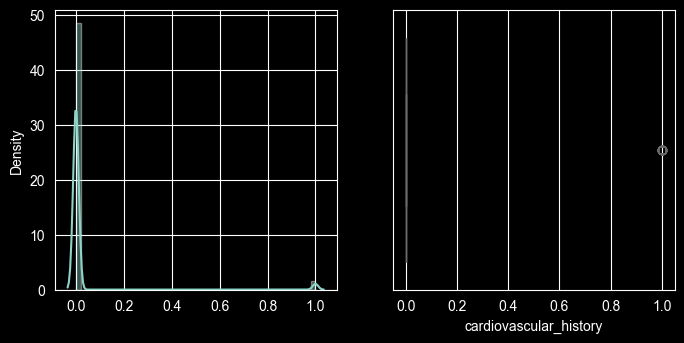

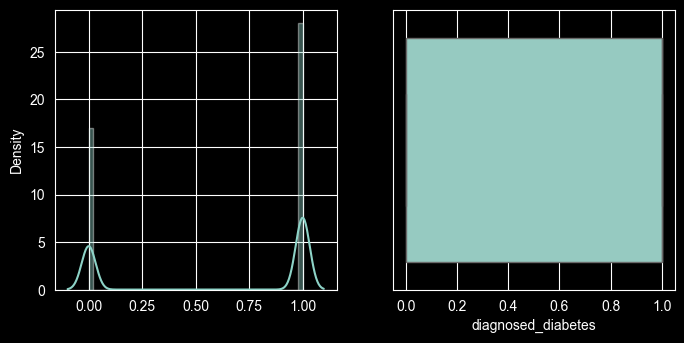

In [34]:
for col in num_cols:
    plt.figure(figsize=(8,8))
    plt.subplot(221)
    sns.distplot(x=df[col],label=col)
    plt.subplot(222)
    sns.boxplot(x=df[col])

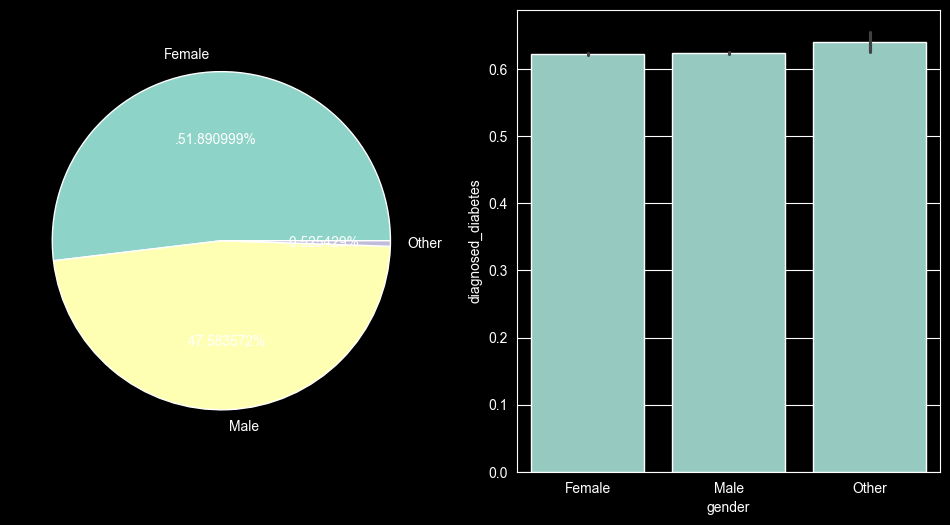

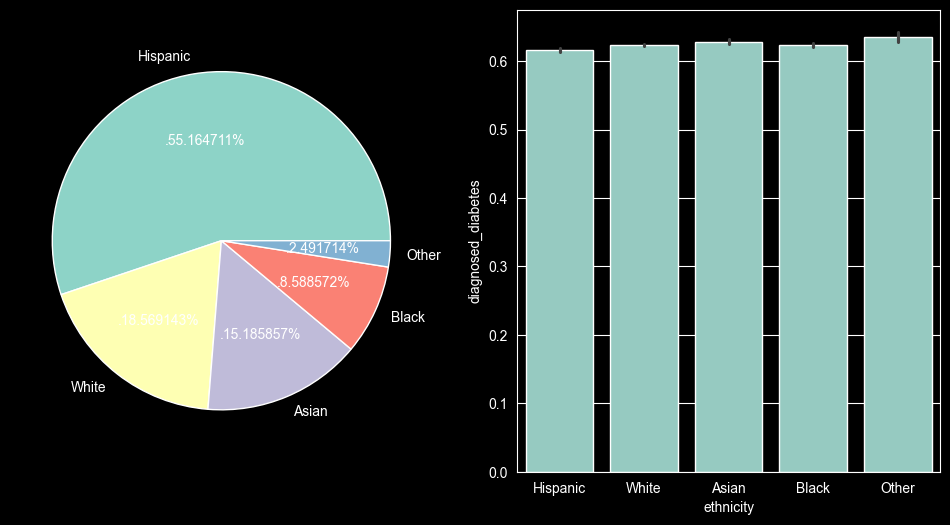

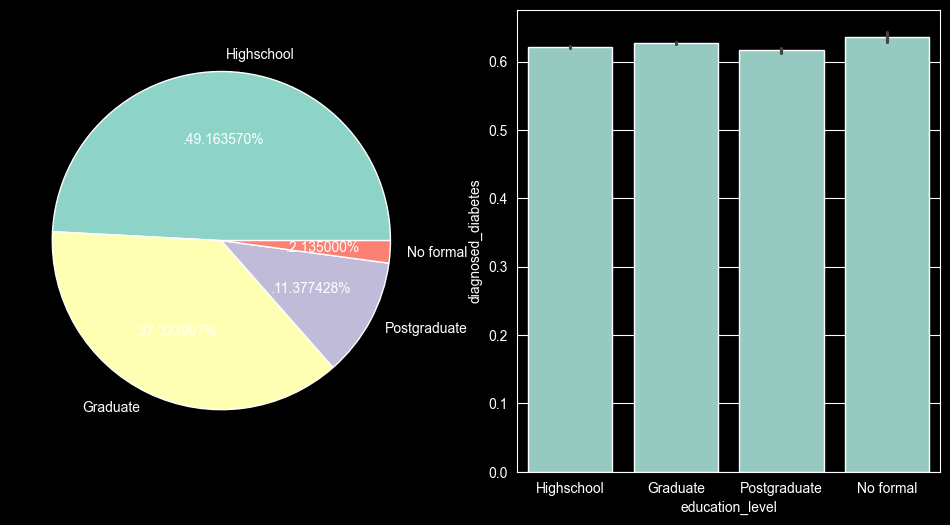

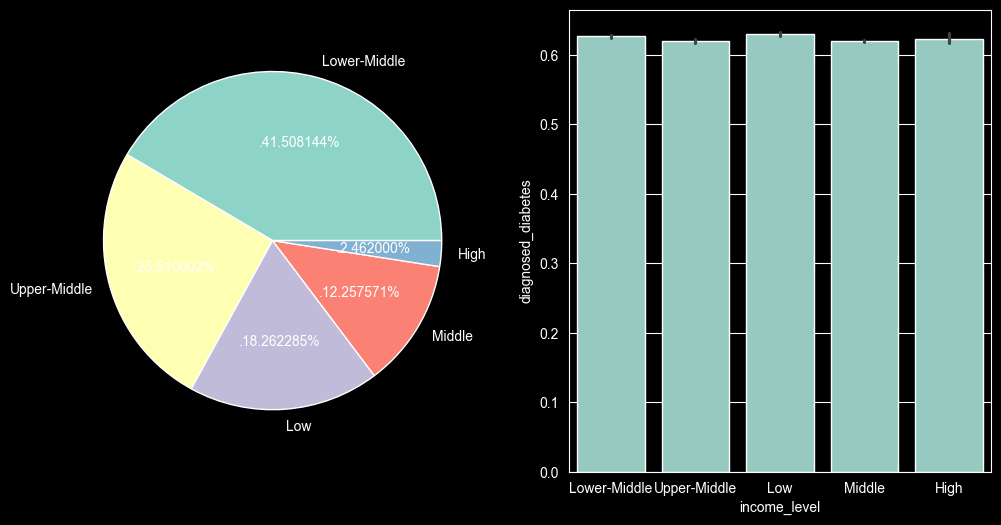

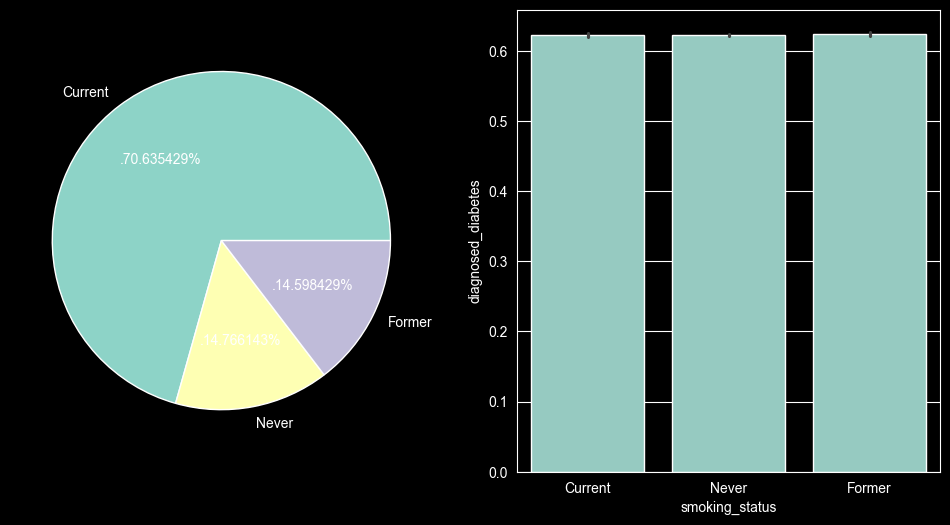

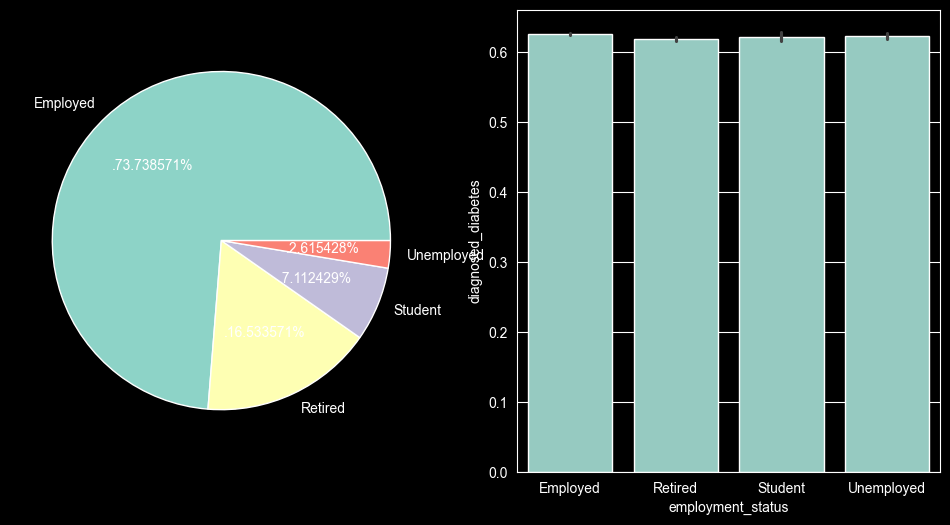

In [35]:
for col in cat_cols:
    size=df[col].value_counts()
    labels=df[col].unique()
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    plt.pie(size,labels=labels,autopct= '.%2f%%')
    plt.subplot(122)
    sns.barplot(x=df[col],y=df['diagnosed_diabetes'])


In [36]:
df.drop(columns=['id'],inplace=True)

In [37]:
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]


In [38]:
from sklearn.model_selection import train_test_split

x=df.drop(columns=['diagnosed_diabetes'])
y=df['diagnosed_diabetes']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
num_cols=x_train.select_dtypes(include='number').columns
cat_cols=x_train.select_dtypes(exclude='number').columns

In [40]:
ohe_cols=['gender','ethnicity']
oe_cols=['education_level','income_level','smoking_status','employment_status']

In [41]:
oe_categories=[]
for col in oe_cols:
    oe_categories.append(df[col].unique())

In [42]:
oe_categories

[array(['Highschool', 'Graduate', 'Postgraduate', 'No formal'],
       dtype=object),
 array(['Lower-Middle', 'Upper-Middle', 'Low', 'Middle', 'High'],
       dtype=object),
 array(['Current', 'Never', 'Former'], dtype=object),
 array(['Employed', 'Retired', 'Student', 'Unemployed'], dtype=object)]

In [43]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [44]:
num_trf=(
    'num',Pipeline([
    ('scaling',StandardScaler())
]),num_cols
)
oe_trf=(
    'oe',Pipeline([
    ('encoding',OrdinalEncoder(categories=oe_categories))
]),oe_cols
)
ohe_trf=(
    'ohe',Pipeline([
    ('encoding',OneHotEncoder(handle_unknown='ignore'))
]),ohe_cols
)

In [45]:
transformer=ColumnTransformer(transformers=[num_trf,oe_trf,ohe_trf],remainder='passthrough')

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report

In [47]:
lr=LogisticRegression()
clf=DecisionTreeClassifier()

pipe_lr=Pipeline([
    ('transformer',transformer),
    ('clf',lr)
])

pipe_clf=Pipeline([
    ('transformer',transformer),
    ('clf',clf)
])

In [48]:
pipe_lr.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('oe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
pipe_clf.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('oe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
y_pred_lr=pipe_lr.predict(x_test)
y_pred_clf=pipe_clf.predict(x_test)

In [51]:
print("Accuracy LR: ",accuracy_score(y_test,y_pred_lr))
print("Accuracy DecisionTreeClassifier: ",accuracy_score(y_test,y_pred_clf))

Accuracy LR:  0.6190356964017455
Accuracy DecisionTreeClassifier:  0.5465102415528054


In [52]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lr)

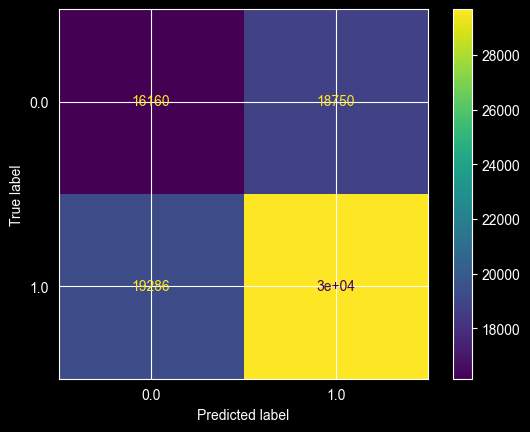

In [53]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_clf)

In [56]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.57      0.34      0.42     34910
         1.0       0.63      0.82      0.72     48964

    accuracy                           0.62     83874
   macro avg       0.60      0.58      0.57     83874
weighted avg       0.61      0.62      0.59     83874



In [57]:
print(classification_report(y_test,y_pred_clf))

              precision    recall  f1-score   support

         0.0       0.46      0.46      0.46     34910
         1.0       0.61      0.61      0.61     48964

    accuracy                           0.55     83874
   macro avg       0.53      0.53      0.53     83874
weighted avg       0.55      0.55      0.55     83874

